# SK Model: GD vs AMP Comparative Benchmark
Sweeps N × matrix modes, collects wall time, FLOP estimates, convergence, and energy accuracy.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import time
import warnings
from itertools import product as iproduct

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


## 1. Core Algorithms (from source script)

In [22]:
# ── Matrix generators ───────────────────────────────────────────────────────

def generate_sk_matrix(N):
    J = np.random.normal(0.0, 1.0 / np.sqrt(N), size=(N, N))
    J = (J + J.T) / np.sqrt(2)
    np.fill_diagonal(J, 0.0)
    return J

# def generate_structured_matrix(N):
#     hidden = np.random.choice([-1.0, 1.0], size=N)
#     J = np.outer(hidden, hidden) / N
#     np.fill_diagonal(J, 0.0)
#     return J, -0.5 * N

# def generate_hopfield_matrix(N, num_patterns=10):
#     J = np.zeros((N, N))
#     for _ in range(num_patterns):
#         p = np.random.choice([-1.0, 1.0], size=N)
#         J += np.outer(p, p)
#     J /= N
#     np.fill_diagonal(J, 0.0)
#     approx_floor = -0.5 * N * (1 + np.sqrt(num_patterns / N))
#     return J, approx_floor

# ── Energy ──────────────────────────────────────────────────────────────────

def calculate_energy(sigma, J):
    return -0.5 * (sigma @ J @ sigma)

# ── Gradient descent ────────────────────────────────────────────────────────

def gradient_descent_sk(J, num_iterations=200, learning_rate=0.1, convergence_tol=1e-5):
    N = J.shape[0]
    sigma = np.random.uniform(-1.0, 1.0, size=N)
    energy_history = []
    convergence_iter = num_iterations  # default: never converged early
    converged = False

    for i in range(num_iterations):
        gradient = -(J @ sigma)          # O(N^2) matmul
        sigma = sigma - learning_rate * gradient
        sigma = np.clip(sigma, -1.0, 1.0)
        e = calculate_energy(sigma, J)
        energy_history.append(float(e))

        if i > 0 and not converged:
            delta = abs(energy_history[-1] - energy_history[-2])
            if delta < convergence_tol * abs(energy_history[-1] + 1e-12):
                convergence_iter = i + 1
                converged = True

    return sigma, energy_history, convergence_iter

# ── AMP ─────────────────────────────────────────────────────────────────────

def amp_sk(J, m_init, num_iterations=500, damping=0.7):
    N = J.shape[0]
    m = np.copy(m_init)
    m_old = np.zeros(N)
    h = np.zeros(N)
    betas = np.linspace(0.1, 2.5, num_iterations)

    for beta in betas:
        onsager = np.mean(1.0 - m**2)
        h_target = J @ m - beta * onsager * m_old   # O(N^2) matmul
        h = damping * h + (1.0 - damping) * h_target
        m_old = np.copy(m)
        m = np.tanh(beta * h)

    return np.sign(m)

def greedy_quench(sigma, J):
    sigma_opt = np.copy(sigma).astype(float)
    N = len(sigma_opt)
    improved = True
    passes = 0

    while improved:
        improved = False
        local_fields = J @ sigma_opt   # O(N^2) per pass
        frustration = sigma_opt * local_fields
        idx = np.argmin(frustration)
        if frustration[idx] < 0:
            sigma_opt[idx] *= -1
            improved = True
        passes += 1

    return sigma_opt, passes

def get_orthogonal_starts(num_starts, N, scale=0.001):
    random_directions = np.random.normal(size=(N, num_starts))
    Q, _ = np.linalg.qr(random_directions)
    return Q.T[:num_starts] * scale

print('Algorithm definitions ready.')

Algorithm definitions ready.


## 2. FLOP Estimators
Each matrix-vector product costs `2N²` FLOPs (multiply-accumulate).

In [23]:
def flops_gd(N, num_iterations, convergence_iter=None):
    """
    Per iteration: one N×N matvec (2N²) + clip + energy matvec (2N²).
    We count both the gradient matvec and the energy evaluation.
    """
    iters = convergence_iter if convergence_iter is not None else num_iterations
    matvecs_per_iter = 2          # gradient + energy eval
    flops_per_matvec = 2 * N * N  # multiply-accumulate
    return iters * matvecs_per_iter * flops_per_matvec

def flops_amp(N, amp_iters, num_restarts, quench_passes_list):
    """
    AMP: one matvec per beta step per restart.
    Quench: one matvec per pass (all restarts).
    """
    amp_flops = num_restarts * amp_iters * (2 * N * N)
    quench_flops = sum(p * 2 * N * N for p in quench_passes_list)
    return amp_flops + quench_flops

print('FLOP estimators defined.')

FLOP estimators defined.


## 3. Sweep Configuration

In [24]:
# ── Sizes to sweep ──────────────────────────────────────────────────────
N_VALUES = [50, 100, 250, 500, 1000, 2000, 3000]
# Add 5000/10000 here if you have the patience — each 10k run takes ~minutes.

MODE = 'RANDOM'  # Only RANDOM mode is used; focus on iteration sweeps
HOPFIELD_PATTERNS = 10

# ── Iteration values to sweep ────────────────────────────────────────────────
ITERATION_VALUES = [100, 250, 500, 1000]

# ── Per-algorithm hyperparams (fixed across N for fair comparison) ──────────
GD_LR          = 0.1
GD_CONV_TOL    = 1e-5

AMP_DAMPING    = 0.7
NUM_RESTARTS   = 10       # orthogonal starts (100 in original; reduced for sweep speed)

print(f'Will sweep N={N_VALUES}')
print(f'Iterations: {ITERATION_VALUES}')
print(f'Mode: {MODE}')
print(f'GD & AMP: {ITERATION_VALUES} iters × {NUM_RESTARTS} restarts (AMP)')

Will sweep N=[50, 100, 250, 500, 1000, 2000, 3000]
Iterations: [100, 250, 500, 1000]
Mode: RANDOM
GD & AMP: [100, 250, 500, 1000] iters × 10 restarts (AMP)


## 4. Main Benchmark Loop

In [25]:
records = []
# Store full convergence curves keyed by (iterations, N)
convergence_curves = {}

total_runs = len(N_VALUES) * len(ITERATION_VALUES)
run_idx = 0

for ITER, N in iproduct(ITERATION_VALUES, N_VALUES):
    run_idx += 1
    print(f'[{run_idx:02d}/{total_runs}]  iterations={ITER:<5d}  N={N:>5d}  ', end='', flush=True)

    # ── Generate matrix ─────────────────────────────────────────────────────
    t0 = time.perf_counter()
    if MODE == 'RANDOM':
        J = generate_sk_matrix(N)
        theoretical_limit = -0.7633 * N
    # elif mode == 'STRUCTURED':
    #     J, theoretical_limit = generate_structured_matrix(N)
    # else:  # HOPFIELD
    #     J, theoretical_limit = generate_hopfield_matrix(N, num_patterns=HOPFIELD_PATTERNS)
    matrix_gen_time = time.perf_counter() - t0

    # ────────────────────────────────────────────────────────────────────────
    # A. Gradient Descent
    # ────────────────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    gd_sigma, gd_curve, gd_conv_iter = gradient_descent_sk(
        J, num_iterations=ITER,
        learning_rate=GD_LR, convergence_tol=GD_CONV_TOL
    )
    gd_wall = time.perf_counter() - t0

    gd_final_energy   = gd_curve[-1]
    gd_gap            = abs(gd_final_energy - theoretical_limit)
    gd_rel_gap        = gd_gap / (abs(theoretical_limit) + 1e-12)
    gd_flops          = flops_gd(N, ITER, gd_conv_iter)

    # ────────────────────────────────────────────────────────────────────────
    # B. AMP multi-start + greedy quench
    # ────────────────────────────────────────────────────────────────────────
    starts = get_orthogonal_starts(NUM_RESTARTS, N)

    amp_best_energy = np.inf
    amp_best_spins  = None
    run_energies    = []
    quench_passes   = []

    t0 = time.perf_counter()
    for k in range(NUM_RESTARTS):
        raw = amp_sk(J, starts[k], num_iterations=ITER, damping=AMP_DAMPING)
        quenched, npasses = greedy_quench(raw, J)
        quench_passes.append(npasses)
        e = calculate_energy(quenched, J)
        run_energies.append(float(e))
        if e < amp_best_energy:
            amp_best_energy = e
            amp_best_spins  = quenched
    amp_wall = time.perf_counter() - t0

    amp_gap     = abs(amp_best_energy - theoretical_limit)
    amp_rel_gap = amp_gap / (abs(theoretical_limit) + 1e-12)
    amp_flops   = flops_amp(N, ITER, NUM_RESTARTS, quench_passes)

    # Convergence metric: which restart first crossed 95% of best energy
    target_95 = 0.95 * amp_best_energy  # energies are negative, so .95× is shallower
    amp_conv_restart = next(
        (i+1 for i, e in enumerate(run_energies) if e <= target_95),
        NUM_RESTARTS
    )

    # ── Store convergence curves for later plotting ──────────────────────────
    convergence_curves[(ITER, N)] = {
        'gd_curve':      gd_curve,
        'amp_per_run':   run_energies,
        'amp_cumulative_best': list(np.minimum.accumulate(run_energies)),
    }

    # ── Assemble record ──────────────────────────────────────────────────────
    rec = dict(
        iterations           = ITER,
        N                    = N,
        theoretical_limit    = round(theoretical_limit, 4),
        # GD stats
        gd_wall_sec          = round(gd_wall, 5),
        gd_final_energy      = round(gd_final_energy, 4),
        gd_gap               = round(gd_gap, 4),
        gd_rel_gap_pct       = round(100 * gd_rel_gap, 4),
        gd_convergence_iter  = gd_conv_iter,
        gd_flops             = gd_flops,
        gd_flops_per_sec     = round(gd_flops / (gd_wall + 1e-12)),
        # AMP stats
        amp_wall_sec         = round(amp_wall, 5),
        amp_best_energy      = round(float(amp_best_energy), 4),
        amp_gap              = round(amp_gap, 4),
        amp_rel_gap_pct      = round(100 * amp_rel_gap, 4),
        amp_conv_restart     = amp_conv_restart,
        amp_total_flops      = amp_flops,
        amp_flops_per_sec    = round(amp_flops / (amp_wall + 1e-12)),
        amp_mean_quench_passes = round(np.mean(quench_passes), 2),
        amp_total_quench_passes = int(np.sum(quench_passes)),
        # Head-to-head
        winner               = 'AMP' if amp_best_energy < gd_final_energy else 'GD',
        energy_improvement   = round(gd_final_energy - amp_best_energy, 4),
        speedup_gd_over_amp  = round(amp_wall / (gd_wall + 1e-12), 3),
    )
    records.append(rec)

    print(f'GD={gd_final_energy:9.2f}  AMP={amp_best_energy:9.2f}  '
          f'limit={theoretical_limit:9.2f}  '
          f'GD_t={gd_wall:.2f}s  AMP_t={amp_wall:.2f}s')

df = pd.DataFrame(records)
print(f'\n✓ Sweep complete. {len(df)} records.')

[01/28]  iterations=100    N=   50  GD=   -28.64  AMP=   -35.95  limit=   -38.16  GD_t=0.00s  AMP_t=0.03s
[02/28]  iterations=100    N=  100  GD=   -58.97  AMP=   -75.08  limit=   -76.33  GD_t=0.00s  AMP_t=0.03s
[03/28]  iterations=100    N=  250  GD=  -158.49  AMP=  -186.19  limit=  -190.82  GD_t=0.00s  AMP_t=0.05s
[04/28]  iterations=100    N=  500  GD=  -305.34  AMP=  -369.09  limit=  -381.65  GD_t=0.00s  AMP_t=0.09s
[05/28]  iterations=100    N= 1000  GD=  -613.56  AMP=  -742.56  limit=  -763.30  GD_t=0.02s  AMP_t=0.29s
[06/28]  iterations=100    N= 2000  GD= -1209.22  AMP= -1470.42  limit= -1526.60  GD_t=0.15s  AMP_t=3.82s
[07/28]  iterations=100    N= 3000  GD= -1849.89  AMP= -2204.08  limit= -2289.90  GD_t=0.54s  AMP_t=18.42s
[08/28]  iterations=250    N=   50  GD=   -34.89  AMP=   -36.57  limit=   -38.16  GD_t=0.00s  AMP_t=0.06s
[09/28]  iterations=250    N=  100  GD=   -64.34  AMP=   -74.55  limit=   -76.33  GD_t=0.00s  AMP_t=0.07s
[10/28]  iterations=250    N=  250  GD=  -162

## 5. Save to CSV

In [26]:
CSV_PATH = 'sk_benchmark_results.csv'
df.to_csv(CSV_PATH, index=False)
print(f'Saved → {CSV_PATH}')
df.head()

Saved → sk_benchmark_results.csv


,iterations,N,theoretical_limit,gd_wall_sec,gd_final_energy,gd_gap,gd_rel_gap_pct,gd_convergence_iter,gd_flops,gd_flops_per_sec,amp_wall_sec,amp_best_energy,amp_gap,amp_rel_gap_pct,amp_conv_restart,amp_total_flops,amp_flops_per_sec,amp_mean_quench_passes,amp_total_quench_passes,winner,energy_improvement,speedup_gd_over_amp
0,100,50,-38.1650,0.0022,-28.6428,9.5222,24.9500,100,1000000,455933994,0.0285,-35.9500,2.2150,5.8037,1,5210000,182771105,4.2000,42,AMP,7.3072,12.9970
1,100,100,-76.3300,0.0017,-58.9748,17.3552,22.7370,100,4000000,2316960159,0.0315,-75.0797,1.2503,1.6380,1,22820000,723681708,14.1000,141,AMP,16.1049,18.2650
2,100,250,-190.8250,0.0031,-158.4929,32.3321,16.9433,100,25000000,8173941456,0.0547,-186.1903,4.6347,2.4288,1,156125000,2856126240,24.9000,249,AMP,27.6974,17.8730
3,100,500,-381.6500,0.0036,-305.3445,76.3055,19.9936,100,100000000,27617443315,0.0912,-369.0949,12.5551,3.2897,1,789000000,8646186859,57.8000,578,AMP,63.7504,25.2020
4,100,1000,-763.3000,0.0181,-613.5582,149.7418,19.6177,100,400000000,22113253146,0.2896,-742.5612,20.7388,2.7170,1,4852000000,16756394422,142.6000,1426,AMP,129.0030,16.0080


## 6. Summary Tables

In [42]:
# Win rate by iterations
print('=== Win Rate (AMP vs GD) by Iterations ===')
win_rate = df.groupby('iterations')['winner'].value_counts(normalize=True).mul(100).round(1)
print(win_rate.to_string())
print()

# Mean relative gap by algo and iterations
print('=== Mean Relative Gap to Theoretical Limit (%) ===')
gap_summary = df.groupby('iterations')[['gd_rel_gap_pct', 'amp_rel_gap_pct']].mean().round(2)
gap_summary.columns = ['GD Gap %', 'AMP Gap %']
print(gap_summary.to_string())
print()

# Wall time ratios
print('=== Mean AMP/GD Wall-Time Ratio by Iterations (>1 = AMP is slower) ===')
df['amp_gd_time_ratio'] = df['amp_wall_sec'] / df['gd_wall_sec']
print(df.groupby('iterations')['amp_gd_time_ratio'].mean().round(2).to_string())

=== Win Rate (AMP vs GD) by Iterations ===
iterations  winner
100         AMP      100.0000
250         AMP      100.0000
500         AMP      100.0000
1000        AMP      100.0000

=== Mean Relative Gap to Theoretical Limit (%) ===
            GD Gap %  AMP Gap %
iterations                     
100          20.6100     3.3300
250          14.5600     3.9000
500          15.3700     4.6600
1000         12.9300     5.2900

=== Mean AMP/GD Wall-Time Ratio by Iterations (>1 = AMP is slower) ===
iterations
100    21.5200
250    14.6300
500    14.0700
1000   13.0500


## 7. Visualizations

In [30]:
# ── Colour palette ──────────────────────────────────────────────────────
ITER_COLORS = {100: '#FF6B6B', 250: '#4ECDC4', 500: '#45B7D1', 1000: '#2E86AB'}
ALGO_COLORS = {'GD': '#E91E63', 'AMP': '#00BCD4'}
ITER_MARKERS = {100: 'o', 250: 's', 500: '^', 1000: 'D'}

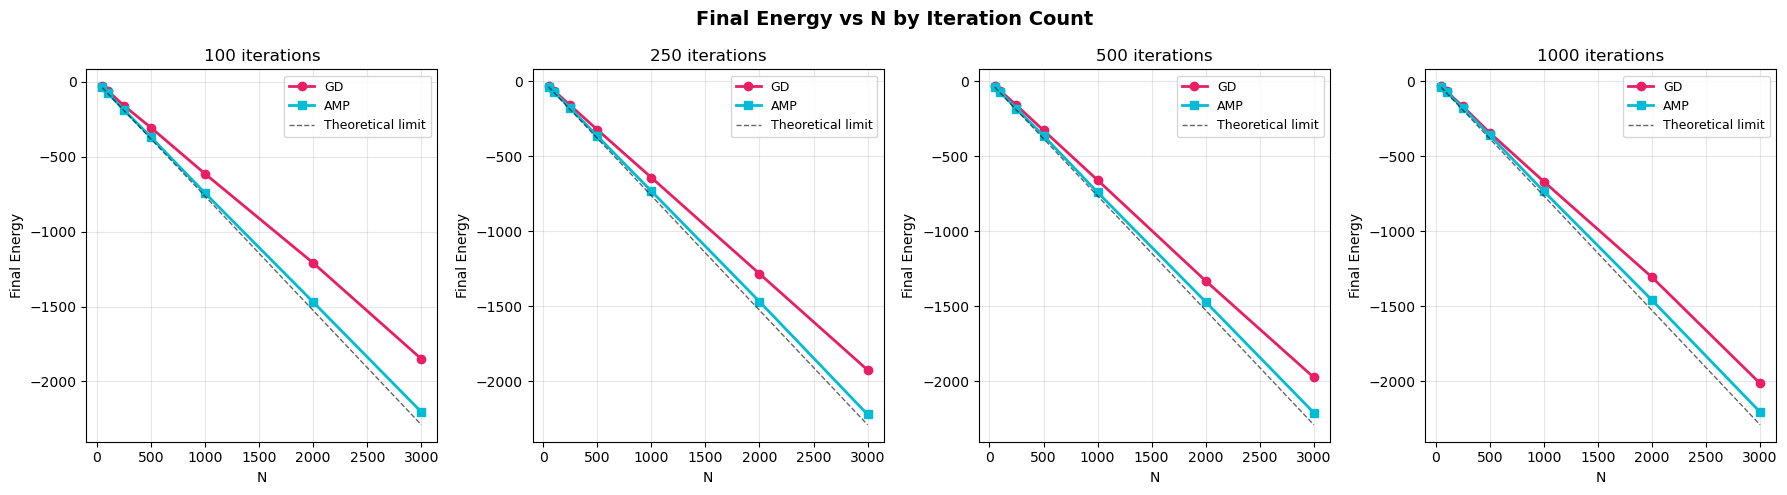

Saved fig1_energy_vs_N.png


In [31]:
# ============================================================
# Figure 1: Final Energy vs N (per iteration count, both algos)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('Final Energy vs N by Iteration Count', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.plot(sub['N'], sub['gd_final_energy'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.plot(sub['N'], sub['amp_best_energy'],   's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.plot(sub['N'], sub['theoretical_limit'], 'k--', label='Theoretical limit', lw=1, alpha=0.6)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Final Energy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_energy_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_energy_vs_N.png')

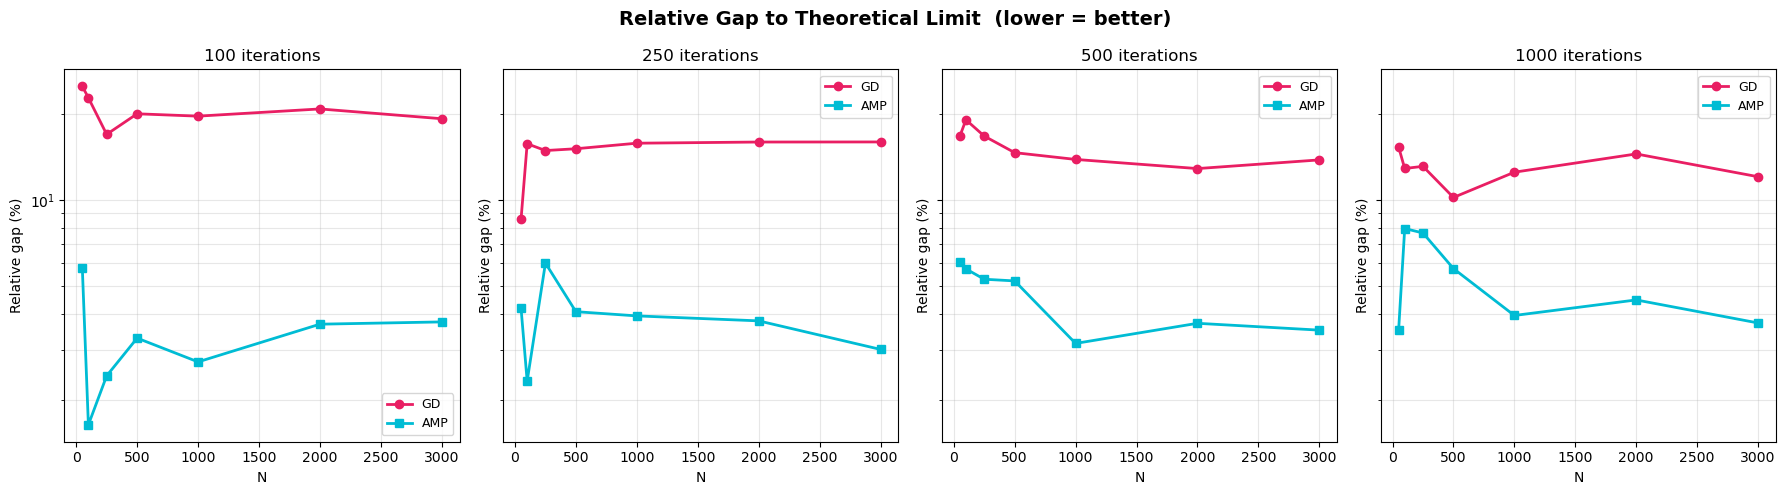

Saved fig2_rel_gap_vs_N.png


In [32]:
# ============================================================
# Figure 2: Relative Gap to Theoretical Limit (% worse)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Relative Gap to Theoretical Limit  (lower = better)', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.semilogy(sub['N'], sub['gd_rel_gap_pct'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.semilogy(sub['N'], sub['amp_rel_gap_pct'],  's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Relative gap (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig2_rel_gap_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_rel_gap_vs_N.png')

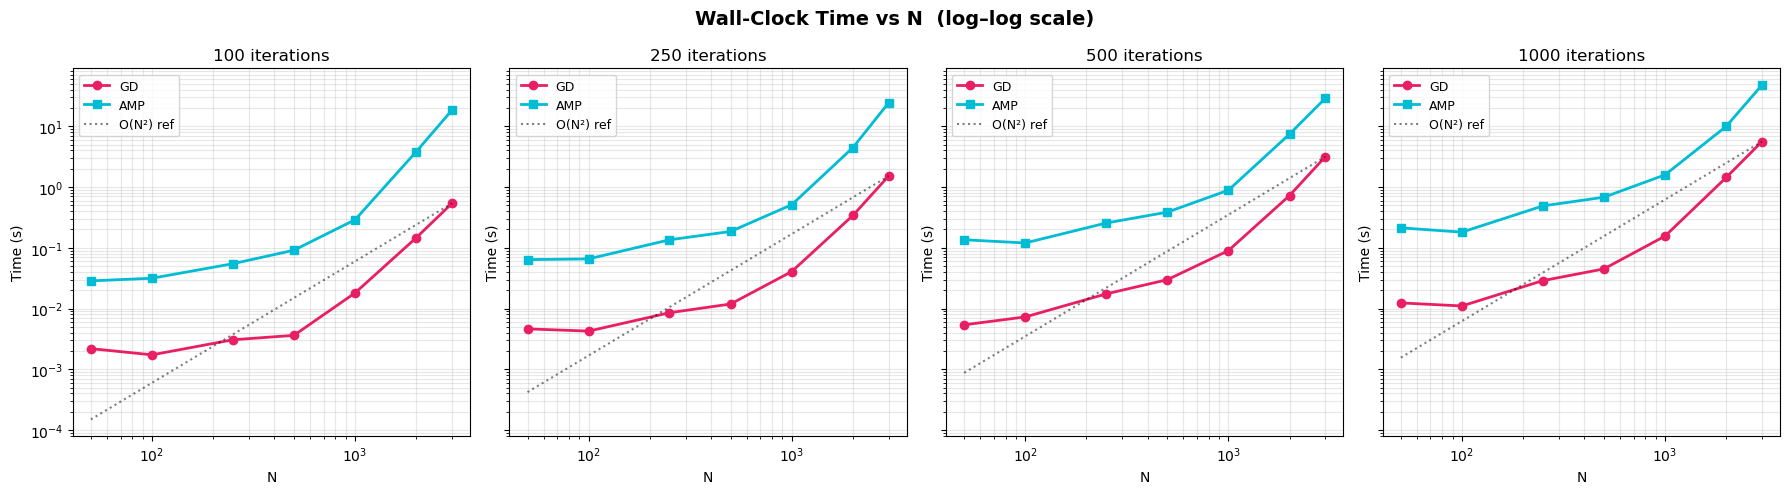

Saved fig3_time_vs_N.png


In [33]:
# ============================================================
# Figure 3: Wall-Clock Time vs N (log-log)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Wall-Clock Time vs N  (log–log scale)', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.loglog(sub['N'], sub['gd_wall_sec'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.loglog(sub['N'], sub['amp_wall_sec'],  's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)

    # Reference O(N^2) line
    ns = np.array(sorted(sub['N']))
    ref = ns**2 / ns[-1]**2 * float(sub[sub['N']==ns[-1]]['gd_wall_sec'])
    ax.loglog(ns, ref, 'k:', alpha=0.5, label='O(N²) ref')

    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Time (s)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig3_time_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_time_vs_N.png')

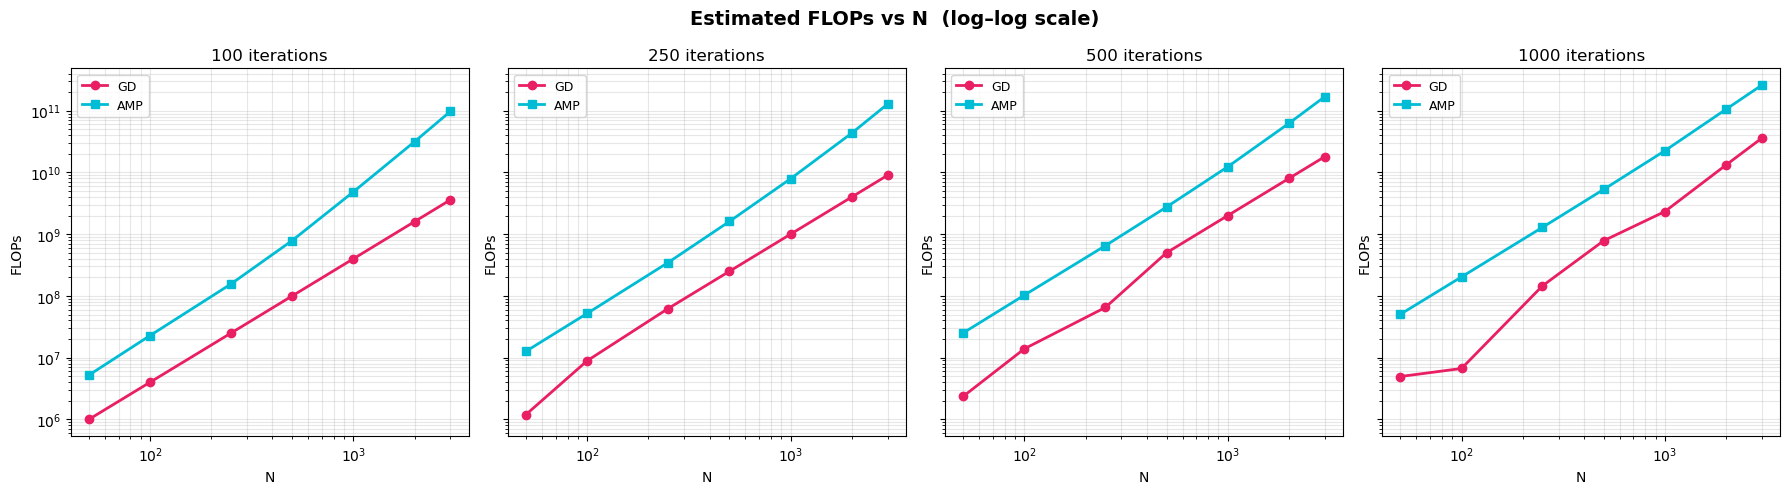

Saved fig4_flops_vs_N.png


In [34]:
# ============================================================
# Figure 4: Estimated FLOPs vs N (log-log)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Estimated FLOPs vs N  (log–log scale)', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.loglog(sub['N'], sub['gd_flops'],         'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.loglog(sub['N'], sub['amp_total_flops'],   's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('FLOPs')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig4_flops_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_flops_vs_N.png')

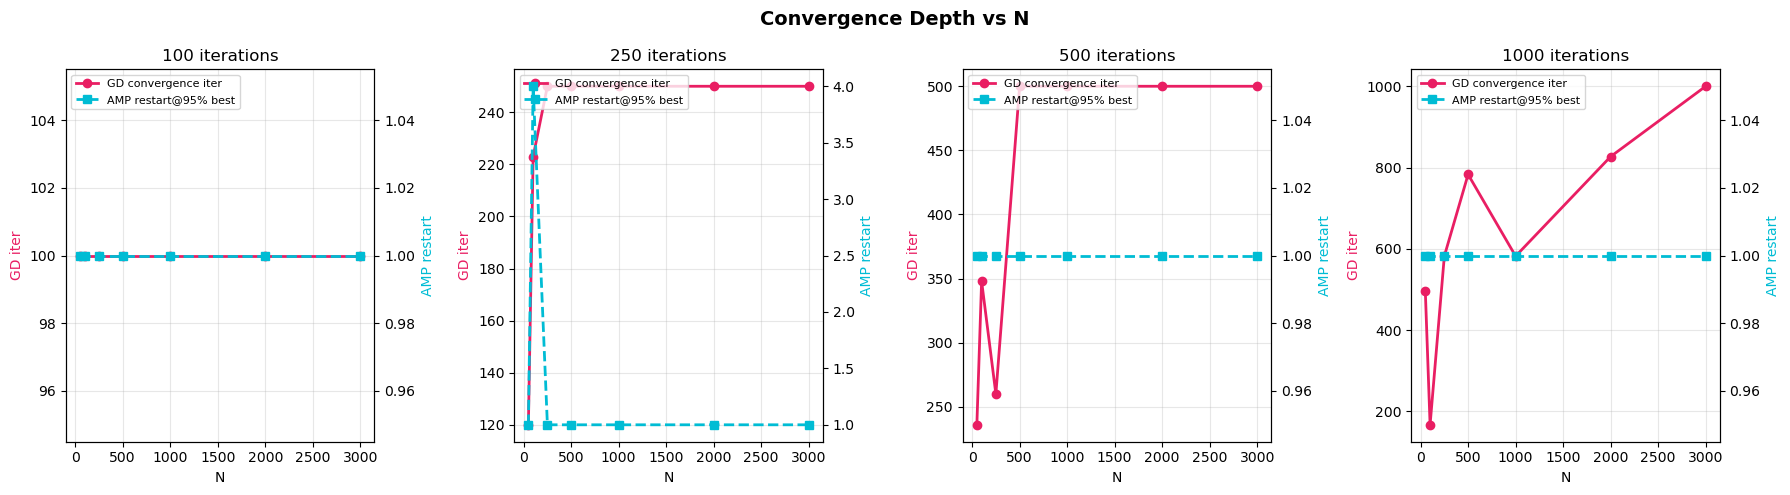

Saved fig5_convergence_depth.png


In [35]:
# ============================================================
# Figure 5: Convergence Iteration (GD) and Restart (AMP) vs N
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('Convergence Depth vs N', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax2 = ax.twinx()
    l1, = ax.plot(sub['N'],  sub['gd_convergence_iter'],  'o-', color=ALGO_COLORS['GD'],  lw=2, label='GD convergence iter')
    l2, = ax2.plot(sub['N'], sub['amp_conv_restart'],     's--', color=ALGO_COLORS['AMP'], lw=2, label='AMP restart@95% best')
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('GD iter', color=ALGO_COLORS['GD'])
    ax2.set_ylabel('AMP restart', color=ALGO_COLORS['AMP'])
    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_convergence_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_convergence_depth.png')

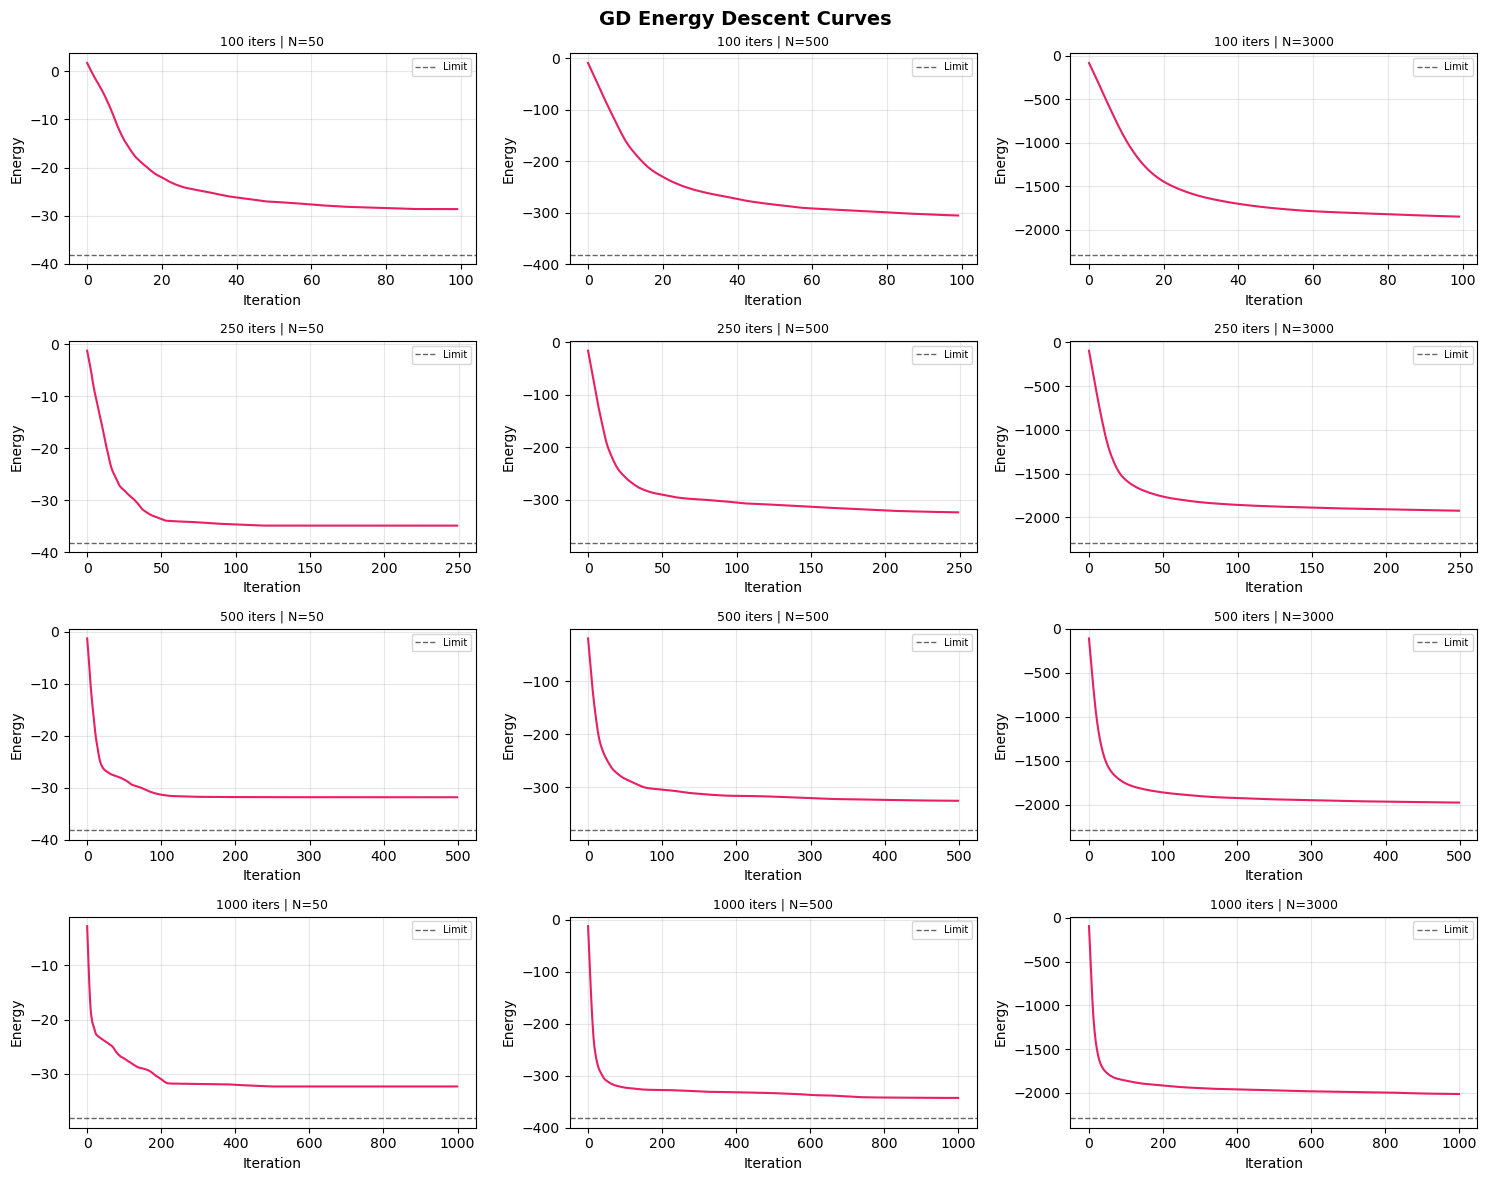

Saved fig6_gd_curves.png


In [36]:
# ============================================================
# Figure 6: GD Energy Convergence Curves (selected N per iteration)
# ============================================================
sample_Ns = [N_VALUES[0], N_VALUES[len(N_VALUES)//2], N_VALUES[-1]]

fig, axes = plt.subplots(len(ITERATION_VALUES), len(sample_Ns), figsize=(15, 12))
fig.suptitle('GD Energy Descent Curves', fontsize=14, fontweight='bold')

for row, iter_val in enumerate(ITERATION_VALUES):
    for col, N in enumerate(sample_Ns):
        ax = axes[row, col]
        key = (iter_val, N)
        if key in convergence_curves:
            curve = convergence_curves[key]['gd_curve']
            limit = df[(df['iterations']==iter_val) & (df['N']==N)]['theoretical_limit'].values[0]
            ax.plot(curve, color=ALGO_COLORS['GD'], lw=1.5)
            ax.axhline(limit, color='k', ls='--', lw=1, alpha=0.6, label='Limit')
            ax.set_title(f'{iter_val} iters | N={N}', fontsize=9)
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Energy')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_gd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_gd_curves.png')

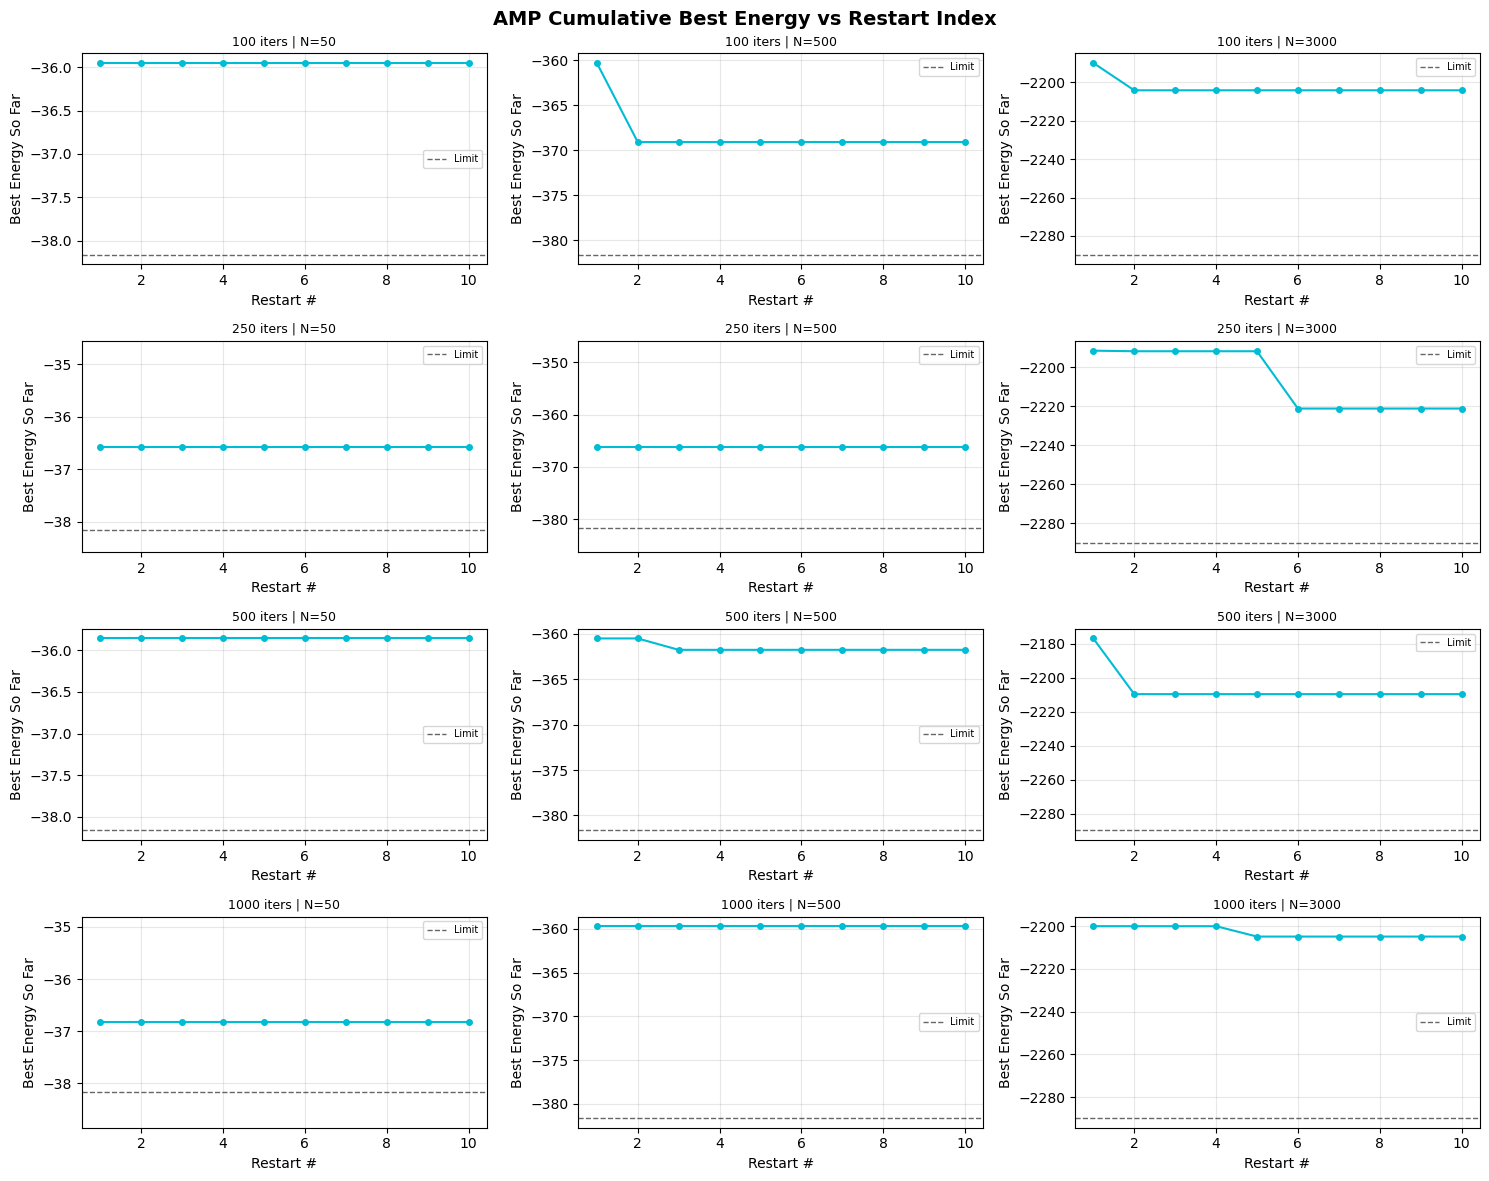

Saved fig7_amp_cumulative.png


In [37]:
# ============================================================
# Figure 7: AMP Cumulative Best Energy Over Restarts
# ============================================================
fig, axes = plt.subplots(len(ITERATION_VALUES), len(sample_Ns), figsize=(15, 12))
fig.suptitle('AMP Cumulative Best Energy vs Restart Index', fontsize=14, fontweight='bold')

for row, iter_val in enumerate(ITERATION_VALUES):
    for col, N in enumerate(sample_Ns):
        ax = axes[row, col]
        key = (iter_val, N)
        if key in convergence_curves:
            cumulative = convergence_curves[key]['amp_cumulative_best']
            limit = df[(df['iterations']==iter_val) & (df['N']==N)]['theoretical_limit'].values[0]
            ax.plot(range(1, len(cumulative)+1), cumulative, color=ALGO_COLORS['AMP'], lw=1.5, marker='o', ms=4)
            ax.axhline(limit, color='k', ls='--', lw=1, alpha=0.6, label='Limit')
            ax.set_title(f'{iter_val} iters | N={N}', fontsize=9)
            ax.set_xlabel('Restart #')
            ax.set_ylabel('Best Energy So Far')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_amp_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_amp_cumulative.png')

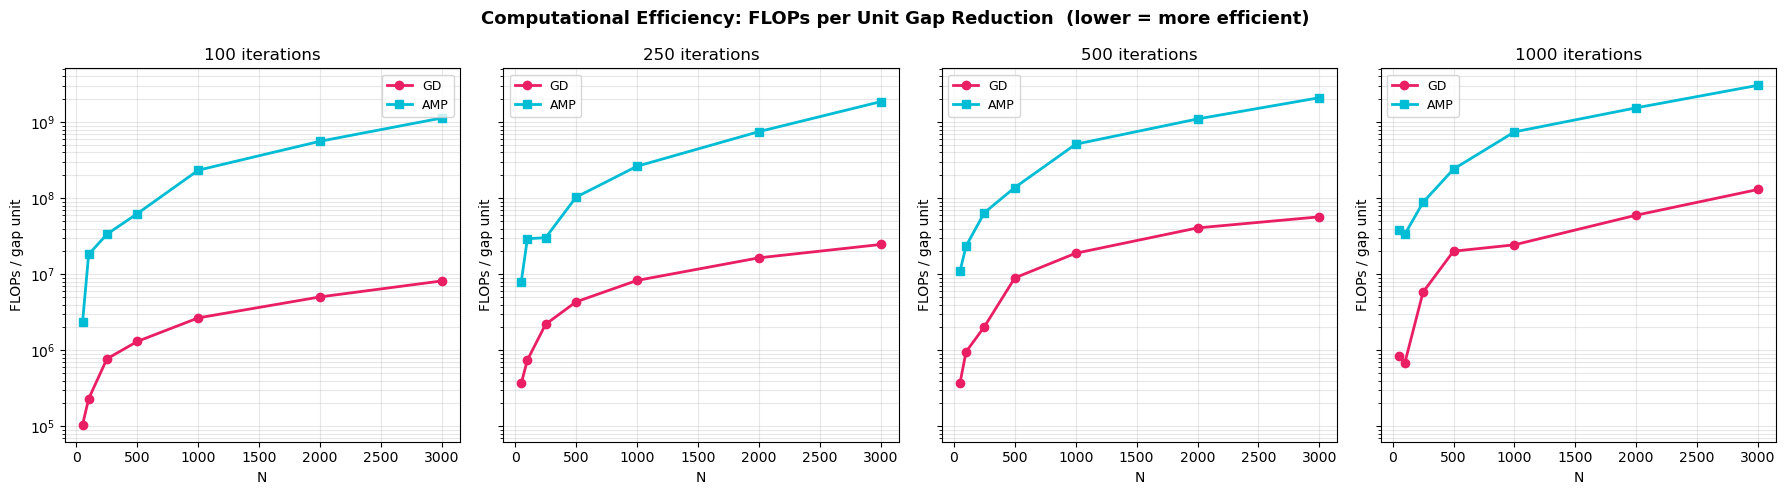

Saved fig8_flop_efficiency.png


In [38]:
# ============================================================
# Figure 8: FLOPs per unit of Energy Improvement (efficiency)
# ============================================================
df['gd_flops_per_energy_unit']  = df['gd_flops']        / (df['gd_gap']  + 1e-6)
df['amp_flops_per_energy_unit'] = df['amp_total_flops'] / (df['amp_gap'] + 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Computational Efficiency: FLOPs per Unit Gap Reduction  (lower = more efficient)', fontsize=13, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.semilogy(sub['N'], sub['gd_flops_per_energy_unit'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.semilogy(sub['N'], sub['amp_flops_per_energy_unit'], 's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('FLOPs / gap unit')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig8_flop_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig8_flop_efficiency.png')

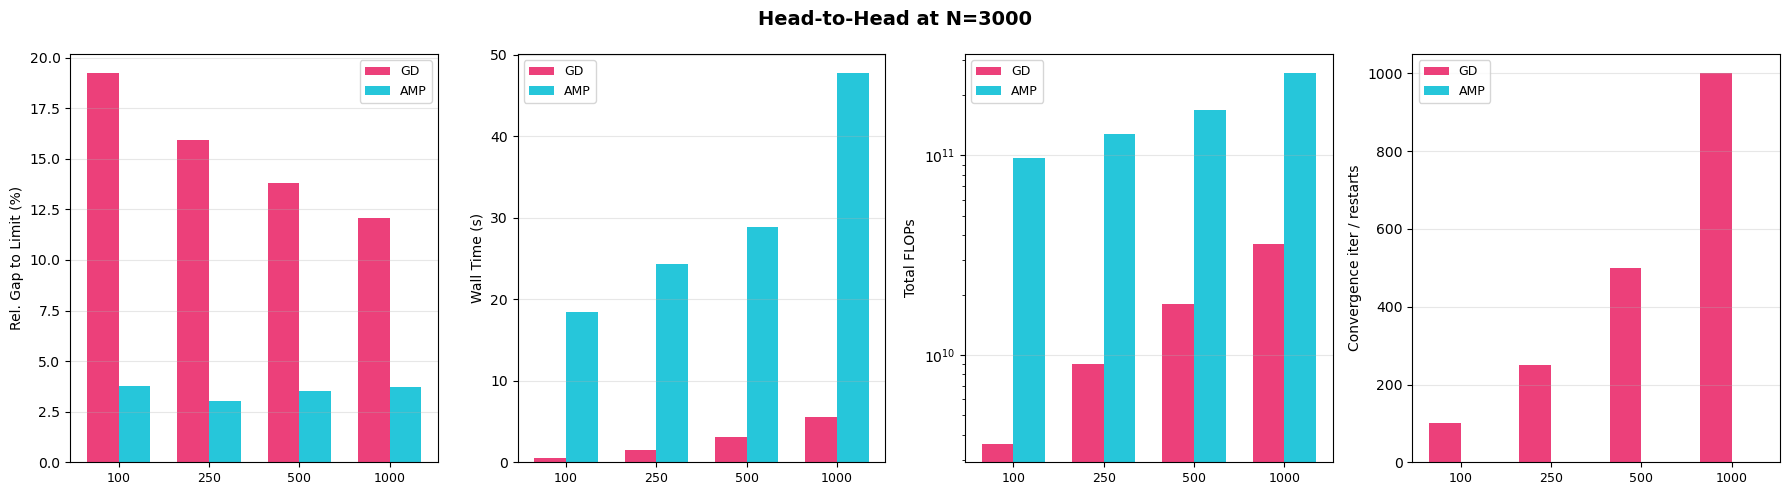

Saved fig9_head_to_head_bar.png


In [39]:
# ============================================================
# Figure 9: Side-by-side bar chart of all metrics at largest N
# ============================================================
largest_N = max(N_VALUES)
sub_large = df[df['N'] == largest_N].copy()

metrics = [
    ('gd_rel_gap_pct',     'amp_rel_gap_pct',     'Rel. Gap to Limit (%)',         False),
    ('gd_wall_sec',        'amp_wall_sec',         'Wall Time (s)',                  False),
    ('gd_flops',           'amp_total_flops',      'Total FLOPs',                   True),
    ('gd_convergence_iter','amp_conv_restart',     'Convergence iter / restarts',   False),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
fig.suptitle(f'Head-to-Head at N={largest_N}', fontsize=14, fontweight='bold')
x = np.arange(len(ITERATION_VALUES))
width = 0.35

for ax, (gd_col, amp_col, ylabel, use_log) in zip(axes, metrics):
    gd_vals  = [float(sub_large[sub_large['iterations']==i][gd_col].values[0])  for i in ITERATION_VALUES]
    amp_vals = [float(sub_large[sub_large['iterations']==i][amp_col].values[0]) for i in ITERATION_VALUES]
    b1 = ax.bar(x - width/2, gd_vals,  width, label='GD',  color=ALGO_COLORS['GD'],  alpha=0.85)
    b2 = ax.bar(x + width/2, amp_vals, width, label='AMP', color=ALGO_COLORS['AMP'], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in ITERATION_VALUES], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if use_log:
        ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig9_head_to_head_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig9_head_to_head_bar.png')

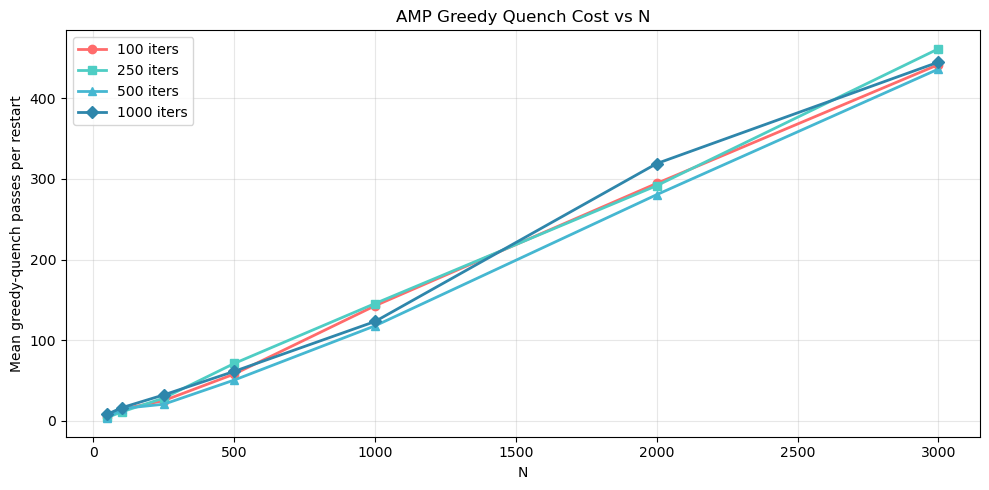

Saved fig10_quench_passes.png


In [43]:
# ============================================================
# Figure 10: Mean Quench Passes (AMP post-processing cost) vs N
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for iter_val in ITERATION_VALUES:
    sub = df[df['iterations'] == iter_val]
    ax.plot(sub['N'], sub['amp_mean_quench_passes'], marker=ITER_MARKERS[iter_val],
            color=ITER_COLORS[iter_val], lw=2, label=f'{iter_val} iters')
ax.set_xlabel('N')
ax.set_ylabel('Mean greedy-quench passes per restart')
ax.set_title('AMP Greedy Quench Cost vs N')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_quench_passes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10_quench_passes.png')

## 8. Full Results Table

In [48]:
display_cols = [
    'N', 'iterations', 'theoretical_limit',
    'gd_final_energy', 'gd_rel_gap_pct', 'gd_wall_sec', 'gd_convergence_iter', 'gd_flops',
    'amp_best_energy', 'amp_rel_gap_pct', 'amp_wall_sec', 'amp_conv_restart', 'amp_total_flops',
    'winner', 'energy_improvement', 'speedup_gd_over_amp'
]

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
df[display_cols].sort_values(['iterations', 'N'])

,N,iterations,theoretical_limit,gd_final_energy,gd_rel_gap_pct,gd_wall_sec,gd_convergence_iter,gd_flops,amp_best_energy,amp_rel_gap_pct,amp_wall_sec,amp_conv_restart,amp_total_flops,winner,energy_improvement,speedup_gd_over_amp
0,50,100,-38.1650,-28.6428,24.9500,0.0022,100,1000000,-35.9500,5.8037,0.0285,1,5210000,AMP,7.3072,12.9970
1,100,100,-76.3300,-58.9748,22.7370,0.0017,100,4000000,-75.0797,1.6380,0.0315,1,22820000,AMP,16.1049,18.2650
2,250,100,-190.8250,-158.4929,16.9433,0.0031,100,25000000,-186.1903,2.4288,0.0547,1,156125000,AMP,27.6974,17.8730
3,500,100,-381.6500,-305.3445,19.9936,0.0036,100,100000000,-369.0949,3.2897,0.0912,1,789000000,AMP,63.7504,25.2020
4,1000,100,-763.3000,-613.5582,19.6177,0.0181,100,400000000,-742.5612,2.7170,0.2896,1,4852000000,AMP,129.0030,16.0080
5,2000,100,-1526.6000,-1209.2232,20.7898,0.1463,100,1600000000,-1470.4239,3.6798,3.8215,1,31560000000,AMP,261.2006,26.1220
6,3000,100,-2289.9000,-1849.8859,19.2154,0.5391,100,3600000000,-2204.0822,3.7477,18.4177,1,97542000000,AMP,354.1962,34.1660
7,50,250,-38.1650,-34.8903,8.5804,0.0046,120,1200000,-36.5713,4.1758,0.0638,1,12700000,AMP,1.6810,13.7990
8,100,250,-76.3300,-64.3372,15.7118,0.0043,223,8920000,-74.5527,2.3284,0.0656,4,52160000,AMP,10.2156,15.4210
9,250,250,-190.8250,-162.4398,14.8750,0.0085,250,62500000,-179.3444,6.0163,0.1353,1,347625000,AMP,16.9046,15.8550
